Prerequisits

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

Parameters and paths

In [ ]:
RGB_IMG_HEIGHT = 224
RGB_IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

COMBINER_EPOCHS = 300
COMBINER_LR = 1e-3
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv")

MODEL3_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
MODEL11_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients")
MODEL11_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL11_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

MODEL3_FINAL_MODEL = MODEL3_DIR / "final_model.keras"

Loading data

In [ ]:
df = pd.read_csv(METADATA_CSV)

print("Loaded file:", METADATA_CSV)
print("Shape before processing:", df.shape)
print("Columns:", df.columns.tolist()[:30], "...")
display(df.head())

Loaded file: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
Shape before processing: (3262, 205)
Columns: ['dish_id', 'total_mass', 'total_carb', 'split', 'source_cafe', 'num_ingredients', 'ingredient_list_str', 'ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy', 'ingr_bread', 'ingr_broccoli', 'ingr_brown_rice'] ...


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_wheat_berry,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
required_cols = ["dish_id", "total_mass", "total_carb", "split", "source_cafe"]
missing_cols = [c for c in required_cols if c not in df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

ingredient_cols = [c for c in df.columns if c.startswith("ingr_")]

if len(ingredient_cols) == 0:
    raise ValueError("No ingredient columns found. Expected columns starting with 'ingr_'.")

print("Number of ingredient columns:", len(ingredient_cols))
print("First 20 ingredient columns:", ingredient_cols[:20])

Number of ingredient columns: 198
First 20 ingredient columns: ['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy']


In [ ]:
df["dish_id"] = df["dish_id"].astype(str).str.strip()

df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except Exception:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after RGB filtering:")
print(df["split"].value_counts(dropna=False))
print("Total remaining:", len(df))
display(df.head())

Empty RGB files: 0

Remaining samples after RGB filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017


Splitting dataset

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


In [ ]:
train_csv = PREP_DIR / "train_model11_rgb_mass_ingr.csv"
val_csv   = PREP_DIR / "val_model11_rgb_mass_ingr.csv"
test_csv  = PREP_DIR / "test_model11_rgb_mass_ingr.csv"
full_csv  = PREP_DIR / "full_model11_rgb_mass_ingr.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/prep_files/train_model11_rgb_mass_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/prep_files/val_model11_rgb_mass_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/prep_files/test_model11_rgb_mass_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/prep_files/full_model11_rgb_mass_ingr.csv


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=RGB_IMG_HEIGHT,
        target_width=RGB_IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_rgb_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    rgb_paths = dataframe["rgb_path"].astype(str).values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [ ]:
train_rgb_dataset = make_rgb_dataset(train_df, batch_size=BATCH_SIZE, shuffle=False)
val_rgb_dataset   = make_rgb_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_rgb_dataset  = make_rgb_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_rgb_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("RGB shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:", batch_labels.shape)

Input keys: dict_keys(['rgb_input'])
RGB shape: (16, 224, 224, 3)
Labels shape: (16,)


Loading trained RGB transformer

In [ ]:
if MODEL3_FINAL_MODEL.exists():
    print("Loading RGB transformer from:", MODEL3_FINAL_MODEL)
    rgb_carb_model = keras.models.load_model(MODEL3_FINAL_MODEL)
else:
    raise FileNotFoundError(f"Could not find Model 3 V3 model at: {MODEL3_FINAL_MODEL}")

Loading RGB transformer from: /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/final_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 896 variables whereas the saved optimizer has 886 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
rgb_carb_model.summary()

Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 1024)      │   304,631,808 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 257, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 911,932,549 (3.40 GB)

 Trainable params: 303,509,889 (1.13 GB)

 Non-trainable params: 1,402,880 (5.35 MB)

 Optimizer params: 607,019,780 (2.26 GB)

Generating RGB carbohydrate predictions

In [ ]:
train_rgb_carb_preds = rgb_carb_model.predict(train_rgb_dataset, verbose=1).reshape(-1)
val_rgb_carb_preds   = rgb_carb_model.predict(val_rgb_dataset, verbose=1).reshape(-1)
test_rgb_carb_preds  = rgb_carb_model.predict(test_rgb_dataset, verbose=1).reshape(-1)

print("Train preds shape:", train_rgb_carb_preds.shape)
print("Val preds shape:  ", val_rgb_carb_preds.shape)
print("Test preds shape: ", test_rgb_carb_preds.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


151/152 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 497s 3s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step
Train preds shape: (2421,)
Val preds shape:   (334,)
Test preds shape:  (507,)


Building combiner dataframe

In [ ]:
base_cols = ["dish_id", "total_carb", "total_mass", "split", "source_cafe"] + ingredient_cols

train_combiner_df = train_df[base_cols].copy().reset_index(drop=True)
val_combiner_df   = val_df[base_cols].copy().reset_index(drop=True)
test_combiner_df  = test_df[base_cols].copy().reset_index(drop=True)

train_combiner_df["rgb_carb_pred"] = train_rgb_carb_preds
val_combiner_df["rgb_carb_pred"]   = val_rgb_carb_preds
test_combiner_df["rgb_carb_pred"]  = test_rgb_carb_preds

display(train_combiner_df.head())

,dish_id,total_carb,total_mass,split,source_cafe,ingr_almonds,ingr_apple,ingr_artichokes,ingr_arugula,ingr_asparagus,...,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_carb_pred
0,dish_1556572657,2.268,36.0,train,cafe1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.041218
1,dish_1556573514,1.219,23.0,train,cafe1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.584430
2,dish_1556575014,3.906,62.0,train,cafe1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.690660
3,dish_1556575083,5.760,64.0,train,cafe1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5.872280
4,dish_1556575124,0.952,28.0,train,cafe1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.847786


In [ ]:
train_combiner_csv = MODEL11_DIR / "train_combiner_features_rgb_mass_ingredients.csv"
val_combiner_csv   = MODEL11_DIR / "val_combiner_features_rgb_mass_ingredients.csv"
test_combiner_csv  = MODEL11_DIR / "test_combiner_features_rgb_mass_ingredients.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print("Saved combiner feature CSVs.")

Saved combiner feature CSVs.


In [ ]:
# Scalar inputs
X_train_rgb  = train_combiner_df[["rgb_carb_pred"]].values.astype("float32")
X_val_rgb    = val_combiner_df[["rgb_carb_pred"]].values.astype("float32")
X_test_rgb   = test_combiner_df[["rgb_carb_pred"]].values.astype("float32")

X_train_mass = train_combiner_df[["total_mass"]].values.astype("float32")
X_val_mass   = val_combiner_df[["total_mass"]].values.astype("float32")
X_test_mass  = test_combiner_df[["total_mass"]].values.astype("float32")

# Ingredient vectors
X_train_ingr = train_combiner_df[ingredient_cols].values.astype("float32")
X_val_ingr   = val_combiner_df[ingredient_cols].values.astype("float32")
X_test_ingr  = test_combiner_df[ingredient_cols].values.astype("float32")

# Targets
y_train = train_combiner_df["total_carb"].values.astype("float32")
y_val   = val_combiner_df["total_carb"].values.astype("float32")
y_test  = test_combiner_df["total_carb"].values.astype("float32")

In [ ]:
print("X_train_rgb:", X_train_rgb.shape)
print("X_train_mass:", X_train_mass.shape)
print("X_train_ingr:", X_train_ingr.shape)
print("y_train:", y_train.shape)

X_train_rgb: (2421, 1)
X_train_mass: (2421, 1)
X_train_ingr: (2421, 198)
y_train: (2421,)


In [ ]:
rgb_scaler = StandardScaler()
mass_scaler = StandardScaler()

X_train_rgb_scaled = rgb_scaler.fit_transform(X_train_rgb).astype("float32")
X_val_rgb_scaled   = rgb_scaler.transform(X_val_rgb).astype("float32")
X_test_rgb_scaled  = rgb_scaler.transform(X_test_rgb).astype("float32")

X_train_mass_scaled = mass_scaler.fit_transform(X_train_mass).astype("float32")
X_val_mass_scaled   = mass_scaler.transform(X_val_mass).astype("float32")
X_test_mass_scaled  = mass_scaler.transform(X_test_mass).astype("float32")

In [ ]:
joblib.dump(rgb_scaler, MODEL11_DIR / "rgb_scaler.joblib")
joblib.dump(mass_scaler, MODEL11_DIR / "mass_scaler.joblib")
print("Saved neural-combiner scalers.")

Saved neural-combiner scalers.


Combiner architecture

In [ ]:
rgb_input = keras.Input(shape=(1,), name="rgb_pred_input")
mass_input = keras.Input(shape=(1,), name="mass_input")
ingredient_input = keras.Input(shape=(len(ingredient_cols),), name="ingredient_input")

rgb_branch = layers.Dense(16, activation="relu")(rgb_input)
rgb_branch = layers.Dropout(0.1)(rgb_branch)

mass_branch = layers.Dense(16, activation="relu")(mass_input)
mass_branch = layers.Dropout(0.1)(mass_branch)

ingredient_branch = layers.Dense(128, activation="relu")(ingredient_input)
ingredient_branch = layers.Dropout(0.2)(ingredient_branch)
ingredient_branch = layers.Dense(64, activation="relu")(ingredient_branch)

fusion = layers.Concatenate()([rgb_branch, mass_branch, ingredient_branch])
fusion = layers.Dense(64, activation="relu")(fusion)
fusion = layers.Dropout(0.2)(fusion)
fusion = layers.Dense(32, activation="relu")(fusion)
output = layers.Dense(1, activation="linear", name="carb_output")(fusion)

combiner_model = keras.Model(
    inputs=[rgb_input, mass_input, ingredient_input],
    outputs=output,
    name="model_11_neural_combiner"
)

In [ ]:
combiner_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=["mae", "mse"]
)

combiner_model.summary()

Model: "model_11_neural_combiner"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ingredient_input    │ (None, 198)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_pred_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     25,472 │ ingredient_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ rgb_pred_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         32 │ mass_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 128)       │          0 │ dense_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 16)        │          0 │ dense[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 16)        │          0 │ dense_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout_24[0][0], │
│ (Concatenate)       │                   │            │ dropout_25[0][0], │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 64)        │          0 │ dense_4[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_output (Dense) │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,113 (164.50 KB)

 Trainable params: 42,113 (164.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
combiner_best_path = MODEL11_DIR / "best_neural_combiner_model.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(combiner_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=200,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=150,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history_combiner = combiner_model.fit(
    {
        "rgb_pred_input": X_train_rgb_scaled,
        "mass_input": X_train_mass_scaled,
        "ingredient_input": X_train_ingr
    },
    y_train,
    validation_data=(
        {
            "rgb_pred_input": X_val_rgb_scaled,
            "mass_input": X_val_mass_scaled,
            "ingredient_input": X_val_ingr
        },
        y_val
    ),
    epochs=COMBINER_EPOCHS,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 557.7193 - mae: 16.8637 - mse: 557.7193
Epoch 1: val_loss improved from None to 136.61302, saving model to /content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/best_neural_combiner_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/best_neural_combiner_model.weights.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 596.1815 - mae: 13.9101 - mse: 596.1815 - val_loss: 136.6130 - val_mae: 9.3881 - val_mse: 136.6130 - learning_rate: 0.0010
Epoch 2/300
65/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 137.4088 - mae: 8.4176 - mse: 137.4088
Epoch 2: val_loss improved from 136.61302 to 68.76832, saving model to /content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/best_neural_combiner_model.weights.h5

Epoch 2: finished saving

In [ ]:
combiner_model.load_weights(str(combiner_best_path))
print("Loaded best neural combiner weights.")

Loaded best neural combiner weights.


Plotting training and validation curves

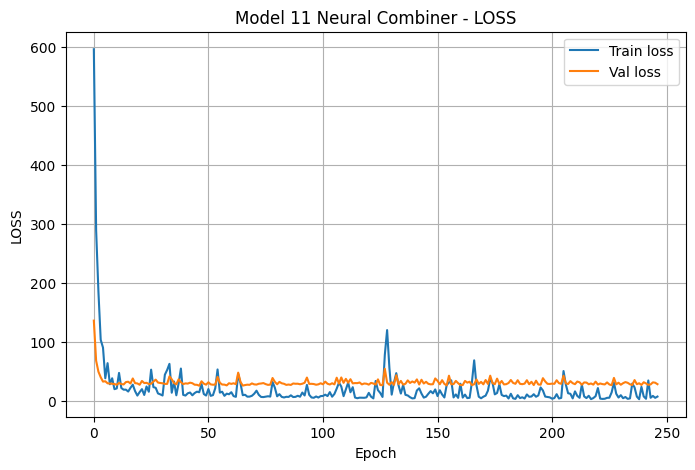

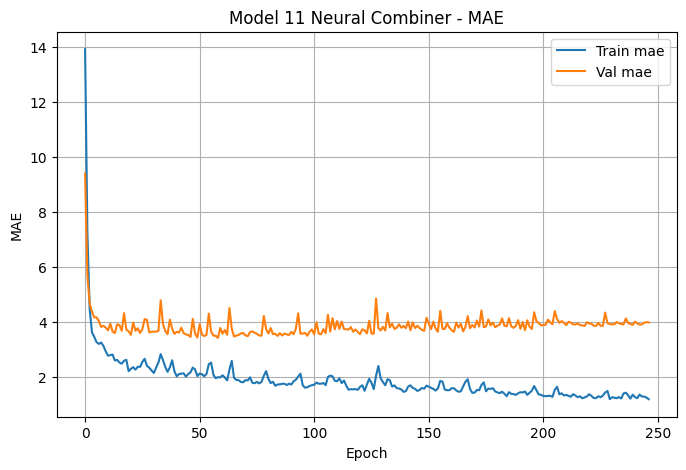

In [ ]:
for metric in ["loss", "mae"]:
    plt.figure(figsize=(8, 5))
    plt.plot(history_combiner.history[metric], label=f"Train {metric}")
    plt.plot(history_combiner.history[f"val_{metric}"], label=f"Val {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.title(f"Model 11 Neural Combiner - {metric.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()

Evaluating combined model

In [ ]:
neural_train_preds = combiner_model.predict(
    {
        "rgb_pred_input": X_train_rgb_scaled,
        "mass_input": X_train_mass_scaled,
        "ingredient_input": X_train_ingr
    },
    verbose=1
).reshape(-1)

neural_val_preds = combiner_model.predict(
    {
        "rgb_pred_input": X_val_rgb_scaled,
        "mass_input": X_val_mass_scaled,
        "ingredient_input": X_val_ingr
    },
    verbose=1
).reshape(-1)

neural_test_preds = combiner_model.predict(
    {
        "rgb_pred_input": X_test_rgb_scaled,
        "mass_input": X_test_mass_scaled,
        "ingredient_input": X_test_ingr
    },
    verbose=1
).reshape(-1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


Classical ML models combiner

In [ ]:
X_train_ml = np.concatenate([X_train_rgb, X_train_mass, X_train_ingr], axis=1).astype("float32")
X_val_ml   = np.concatenate([X_val_rgb, X_val_mass, X_val_ingr], axis=1).astype("float32")
X_test_ml  = np.concatenate([X_test_rgb, X_test_mass, X_test_ingr], axis=1).astype("float32")

print("X_train_ml:", X_train_ml.shape)
print("X_val_ml:  ", X_val_ml.shape)
print("X_test_ml: ", X_test_ml.shape)

X_train_ml: (2421, 200)
X_val_ml:   (334, 200)
X_test_ml:  (507, 200)


Helper function for PMAE calculation

In [ ]:
def compute_pmae(y_true, y_pred, min_target=5.0):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.maximum(np.abs(y_true), min_target)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)

In [ ]:
def build_metric_row(model_name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    return {
        "model": model_name,

        "train_mae": float(mean_absolute_error(y_train, train_pred)),
        "train_mse": float(mean_squared_error(y_train, train_pred)),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, train_pred))),
        "train_r2": float(r2_score(y_train, train_pred)),
        "train_pmae": float(compute_pmae(y_train, train_pred)),

        "val_mae": float(mean_absolute_error(y_val, val_pred)),
        "val_mse": float(mean_squared_error(y_val, val_pred)),
        "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_pred))),
        "val_r2": float(r2_score(y_val, val_pred)),
        "val_pmae": float(compute_pmae(y_val, val_pred)),

        "test_mae": float(mean_absolute_error(y_test, test_pred)),
        "test_mse": float(mean_squared_error(y_test, test_pred)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, test_pred))),
        "test_r2": float(r2_score(y_test, test_pred)),
        "test_pmae": float(compute_pmae(y_test, test_pred)),
    }

Training LR and XGB

In [ ]:
models = {}

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_ml, y_train)
models["LinearRegression"] = lr_model

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=SEED
)

xgb_model.fit(
    X_train_ml,
    y_train,
    eval_set=[(X_val_ml, y_val)],
    verbose=False
)
models["XGBoost"] = xgb_model

print("Fitted models:", list(models.keys()))

Fitted models: ['LinearRegression', 'XGBoost']


Predicting with classical model + ensembling the two

In [ ]:
train_preds = {}
val_preds = {}
test_preds = {}

for model_name, model in models.items():
    train_preds[model_name] = model.predict(X_train_ml).reshape(-1)
    val_preds[model_name]   = model.predict(X_val_ml).reshape(-1)
    test_preds[model_name]  = model.predict(X_test_ml).reshape(-1)

In [ ]:
ensemble_model_names = list(models.keys())

train_preds["ML_Ensemble_Average"] = np.mean(
    np.column_stack([train_preds[m] for m in ensemble_model_names]),
    axis=1
)

val_preds["ML_Ensemble_Average"] = np.mean(
    np.column_stack([val_preds[m] for m in ensemble_model_names]),
    axis=1
)

test_preds["ML_Ensemble_Average"] = np.mean(
    np.column_stack([test_preds[m] for m in ensemble_model_names]),
    axis=1
)

print("ML ensemble built from:", ensemble_model_names)

ML ensemble built from: ['LinearRegression', 'XGBoost']


Comparing all models

In [ ]:
results = []

# RGB-only baseline
results.append(build_metric_row(
    "RGB_only_baseline",
    y_train, train_combiner_df["rgb_carb_pred"].values,
    y_val,   val_combiner_df["rgb_carb_pred"].values,
    y_test,  test_combiner_df["rgb_carb_pred"].values
))

# Neural combiner
results.append(build_metric_row(
    "Model_11_Neural_Combiner",
    y_train, neural_train_preds,
    y_val,   neural_val_preds,
    y_test,  neural_test_preds
))

# Classical models
for model_name in list(models.keys()) + ["ML_Ensemble_Average"]:
    results.append(build_metric_row(
        f"Model_11_{model_name}",
        y_train, train_preds[model_name],
        y_val,   val_preds[model_name],
        y_test,  test_preds[model_name]
    ))

results_df = pd.DataFrame(results).sort_values("val_mae", ascending=True).reset_index(drop=True)
display(results_df)

,model,train_mae,train_mse,train_rmse,train_r2,train_pmae,val_mae,val_mse,val_rmse,val_r2,val_pmae,test_mae,test_mse,test_rmse,test_r2,test_pmae
0,Model_11_Neural_Combiner,1.327314,24.252747,4.924708,0.954557,8.208334,3.450671,26.429605,5.140973,0.883958,20.169800,4.044664,44.950291,6.704498,0.851907,20.882904
1,Model_11_LinearRegression,1.137605,3.812257,1.952500,0.992857,7.598527,4.299718,40.782856,6.386146,0.820939,26.876152,4.690073,55.699135,7.463185,0.816494,26.535372
2,Model_11_ML_Ensemble_Average,1.068627,2.712712,1.647031,0.994917,7.038042,4.351120,41.570972,6.447556,0.817478,27.967396,4.700233,56.216785,7.497785,0.814789,26.716599
3,Model_11_XGBoost,1.105203,2.538762,1.593349,0.995243,7.408173,4.455568,42.882591,6.548480,0.811720,29.490099,4.753984,57.246078,7.566114,0.811398,27.397797
4,RGB_only_baseline,1.432568,6.344157,2.518761,0.988113,8.969028,4.529927,44.718330,6.687177,0.803660,29.068226,4.765221,57.263653,7.567275,0.811340,26.878647


In [ ]:
results_csv = MODEL11_DIR / "model11_comparison_all_combiners.csv"
results_df.to_csv(results_csv, index=False)
print("Saved results to:", results_csv)

Saved results to: /content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/model11_comparison_all_combiners.csv


Saving trained model

In [ ]:
combiner_model.save(MODEL11_DIR / "model11_neural_combiner.keras")
joblib.dump(lr_model, MODEL11_DIR / "model11_linear_regression.joblib")

if "MARS" in models:
    joblib.dump(models["MARS"], MODEL11_DIR / "model11_mars.joblib")

joblib.dump(xgb_model, MODEL11_DIR / "model11_xgboost.joblib")

print("Saved trained Model 11 combiners.")

Saved trained Model 11 combiners.


Building full test prediction dataframe

In [ ]:
test_results_df = test_combiner_df.copy()

test_results_df["rgb_only_pred"] = test_combiner_df["rgb_carb_pred"]
test_results_df["model11_neural_pred"] = neural_test_preds

if "LinearRegression" in test_preds:
    test_results_df["model11_lr_pred"] = test_preds["LinearRegression"]

if "MARS" in test_preds:
    test_results_df["model11_mars_pred"] = test_preds["MARS"]

if "XGBoost" in test_preds:
    test_results_df["model11_xgb_pred"] = test_preds["XGBoost"]

test_results_df["model11_ml_ensemble_pred"] = test_preds["ML_Ensemble_Average"]

best_model_name = results_df.iloc[0]["model"]
print("Best model by validation MAE:", best_model_name)

Best model by validation MAE: Model_11_Neural_Combiner


In [ ]:
if best_model_name == "RGB_only_baseline":
    test_results_df["final_pred"] = test_results_df["rgb_only_pred"]
elif best_model_name == "Model_11_Neural_Combiner":
    test_results_df["final_pred"] = test_results_df["model11_neural_pred"]
elif best_model_name == "Model_11_LinearRegression":
    test_results_df["final_pred"] = test_results_df["model11_lr_pred"]
elif best_model_name == "Model_11_MARS":
    test_results_df["final_pred"] = test_results_df["model11_mars_pred"]
elif best_model_name == "Model_11_XGBoost":
    test_results_df["final_pred"] = test_results_df["model11_xgb_pred"]
elif best_model_name == "Model_11_ML_Ensemble_Average":
    test_results_df["final_pred"] = test_results_df["model11_ml_ensemble_pred"]

test_results_df["abs_error"] = np.abs(test_results_df["total_carb"] - test_results_df["final_pred"])
test_results_df["abs_error_rgb_only"] = np.abs(test_results_df["total_carb"] - test_results_df["rgb_only_pred"])

predictions_csv = MODEL11_DIR / "model11_test_predictions_all_combiners.csv"
test_results_df.to_csv(predictions_csv, index=False)

print("Saved test predictions to:", predictions_csv)
display(test_results_df.head())

Saved test predictions to: /content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/model11_test_predictions_all_combiners.csv


,dish_id,total_carb,total_mass,split,source_cafe,ingr_almonds,ingr_apple,ingr_artichokes,ingr_arugula,ingr_asparagus,...,ingr_zucchini,rgb_carb_pred,rgb_only_pred,model11_neural_pred,model11_lr_pred,model11_xgb_pred,model11_ml_ensemble_pred,final_pred,abs_error,abs_error_rgb_only
0,dish_1556575327,10.618,152.0,test,cafe1,0,0,0,0,0,...,0,12.507236,12.507236,11.006642,12.062748,13.153951,12.608349,11.006642,0.388642,1.889236
1,dish_1557861216,0.000,1.0,test,cafe1,0,0,0,0,0,...,0,1.025138,1.025138,0.209952,1.638230,0.961759,1.299994,0.209952,0.209952,1.025138
2,dish_1557862345,0.000,63.0,test,cafe1,0,0,0,0,0,...,0,1.074629,1.074629,1.380343,0.717706,1.053801,0.885753,1.380343,1.380343,1.074629
3,dish_1557862696,3.850,77.0,test,cafe1,0,0,0,0,0,...,0,3.543902,3.543902,3.243767,4.262258,4.218125,4.240191,3.243767,0.606233,0.306098
4,dish_1557862738,0.000,118.0,test,cafe1,0,0,0,0,0,...,0,4.563577,4.563577,3.049726,3.658967,4.904062,4.281515,3.049726,3.049726,4.563577


Top 10 best and worst dishes

In [ ]:
best_10 = test_results_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_results_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[[
    "dish_id", "total_carb", "total_mass",
    "rgb_only_pred", "final_pred", "abs_error"
]])

print("Top 10 worst predictions:")
display(worst_10[[
    "dish_id", "total_carb", "total_mass",
    "rgb_only_pred", "final_pred", "abs_error"
]])

Top 10 best predictions:


,dish_id,total_carb,total_mass,rgb_only_pred,final_pred,abs_error
393,dish_1565035715,3.510000,39.0,2.622138,3.524030,0.014030
60,dish_1558461692,9.080000,40.0,10.426931,9.094395,0.014395
344,dish_1563996441,2.617095,65.0,2.482283,2.633007,0.015912
187,dish_1560975572,16.068001,159.0,17.093866,16.050077,0.017924
180,dish_1560801773,2.700000,54.0,3.416123,2.672523,0.027477
147,dish_1560367904,3.734912,69.0,3.499450,3.780869,0.045957
156,dish_1560444869,3.510000,39.0,3.832709,3.558361,0.048361
366,dish_1564686966,2.514239,65.0,2.260157,2.463495,0.050744
435,dish_1565898432,11.596747,282.0,13.065634,11.659099,0.062352
157,dish_1560444892,10.139999,90.0,7.330606,10.070512,0.069487


Top 10 worst predictions:


,dish_id,total_carb,total_mass,rgb_only_pred,final_pred,abs_error
178,dish_1560801020,61.690983,250.0,27.431894,23.118252,38.572731
179,dish_1560801041,63.245892,292.0,29.548124,26.254803,36.991089
177,dish_1560800988,61.249092,230.0,28.556852,25.038021,36.211071
247,dish_1562009934,62.243580,369.0,33.657280,33.579182,28.664398
150,dish_1560367980,47.243912,254.0,16.448000,19.555120,27.688792
149,dish_1560367952,45.956913,221.0,13.091601,18.399498,27.557415
318,dish_1563551220,79.790924,558.0,52.106049,53.778587,26.012337
447,dish_1566328831,85.809998,500.0,60.453506,61.548473,24.261525
446,dish_1566328805,85.054001,488.0,57.366875,61.716244,23.337757
325,dish_1563566909,46.750000,187.0,20.878225,23.528816,23.221184


Saving summary

In [ ]:
summary = {
    "model_name": "Model 11 - ViT overhead RGB + actual mass + actual ingredients",
    "num_ingredient_features": int(len(ingredient_cols)),
    "best_model_by_val_mae": str(best_model_name),
    "results_sorted_by_val_mae": results_df.to_dict(orient="records")
}

summary_path = MODEL11_DIR / "model11_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)

Saved summary to: /content/drive/MyDrive/Speciale/Models/Model_11_ViT_overhead_RGB_plus_actual_mass_plus_actual_ingredients/model11_summary.json
